# 03_analysis_visualization

This notebook analyzes football player statistics and visualizes the relationship between player performance and market value. It covers exploratory data analysis, correlation analysis, statistical tests (OLS regression, t-test), and market value insights.

## Setup & Imports

In [1]:
# Import required libraries
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Ensure data directory exists before any database operations
os.makedirs("data", exist_ok=True)

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid")

# ── Load data ───────────────────────────────────────────────────────────────
db_path = "data/football.db"
connection = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM players_cleaned", connection)
connection.close()

print(f"✓ Loaded {len(df)} records from players_cleaned")
print(f"Columns: {list(df.columns)}")
display(df.head(5))

✓ Loaded 351 records from players_cleaned
Columns: ['player_id', 'name', 'nationality', 'date_of_birth', 'team_id', 'team_name', 'position', 'market_value', 'market_value_numeric', 'market_value_tm', 'position_group', 'age', 'has_market_value']


,player_id,name,nationality,date_of_birth,team_id,team_name,position,market_value,market_value_numeric,market_value_tm,position_group,age,has_market_value
0,1731,Gianluigi Donnarumma,Italy,1999-02-25,65,Manchester City FC,Goalkeeper,14.2,14.2,14.2,Goalkeeper,27,1
1,3953,Marcus Bettinelli,England,1992-05-24,65,Manchester City FC,Goalkeeper,6.4,6.4,6.4,Goalkeeper,34,1
2,153874,James Trafford,England,2002-10-10,65,Manchester City FC,Goalkeeper,5.8,5.8,5.8,Goalkeeper,23,1
3,270613,Kaden Braithwaite,England,2008-03-25,65,Manchester City FC,Defender,37.1,37.1,37.1,Defender,18,1
4,290970,Kian Noble,England,2007-02-26,65,Manchester City FC,Defender,36.4,36.4,36.4,Defender,19,1


## Exploratory Data Analysis (EDA)

Visual overview of the dataset: player counts by position, nationality breakdown, and age distributions.

/var/folders/pl/m1n84j6131j8l7hjlwgc85zh0000gq/T/ipykernel_95239/3850057170.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=position_counts, x="position_group", y="count",


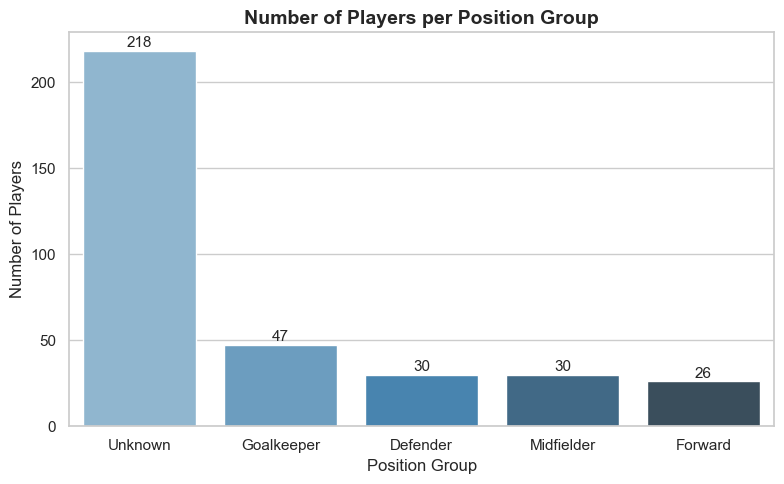

In [2]:
def plot_players_per_position(dataframe):
    """Bar chart showing the number of players per position group."""
    # Count players in each position group
    position_counts = dataframe["position_group"].value_counts().reset_index()
    position_counts.columns = ["position_group", "count"]

    fig, ax = plt.subplots(figsize=(8, 5))

    # Draw bars with seaborn for consistent styling
    sns.barplot(data=position_counts, x="position_group", y="count",
                palette="Blues_d", ax=ax)

    # Labels and title
    ax.set_title("Number of Players per Position Group", fontsize=14, fontweight="bold")
    ax.set_xlabel("Position Group", fontsize=12)
    ax.set_ylabel("Number of Players", fontsize=12)

    # Annotate bar heights
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                int(bar.get_height()),
                ha="center", va="bottom", fontsize=11)

    plt.tight_layout()
    plt.show()

plot_players_per_position(df)

/var/folders/pl/m1n84j6131j8l7hjlwgc85zh0000gq/T/ipykernel_95239/491421729.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_nat, x="nationality", y="count",


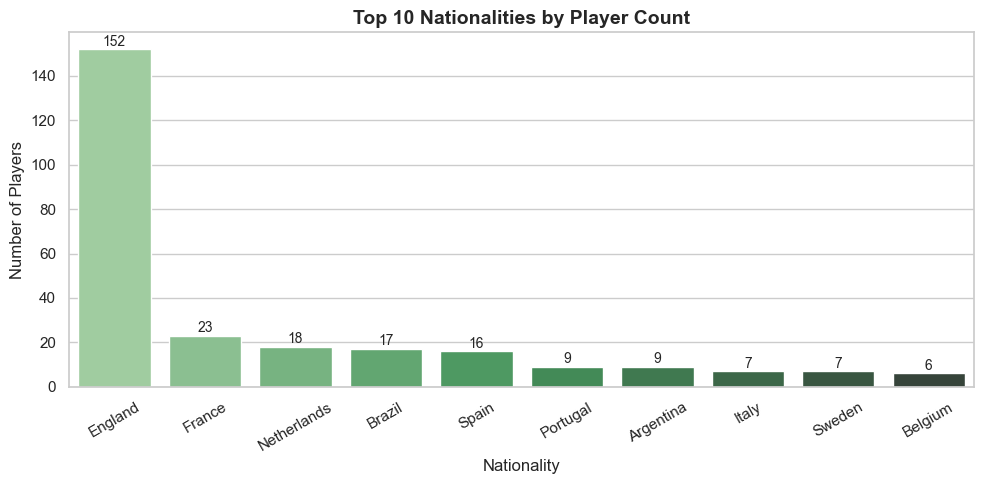

In [3]:
def plot_top_nationalities(dataframe, top_n=10):
    """Bar chart of the top N nationalities represented in the dataset."""
    # Get top N nationalities by player count
    top_nat = (dataframe["nationality"]
               .value_counts()
               .head(top_n)
               .reset_index())
    top_nat.columns = ["nationality", "count"]

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(data=top_nat, x="nationality", y="count",
                palette="Greens_d", ax=ax)

    ax.set_title(f"Top {top_n} Nationalities by Player Count", fontsize=14, fontweight="bold")
    ax.set_xlabel("Nationality", fontsize=12)
    ax.set_ylabel("Number of Players", fontsize=12)
    ax.tick_params(axis="x", rotation=30)

    # Annotate bar heights
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                int(bar.get_height()),
                ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_top_nationalities(df)

/var/folders/pl/m1n84j6131j8l7hjlwgc85zh0000gq/T/ipykernel_95239/3411601367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_data, x="position_group", y="age",


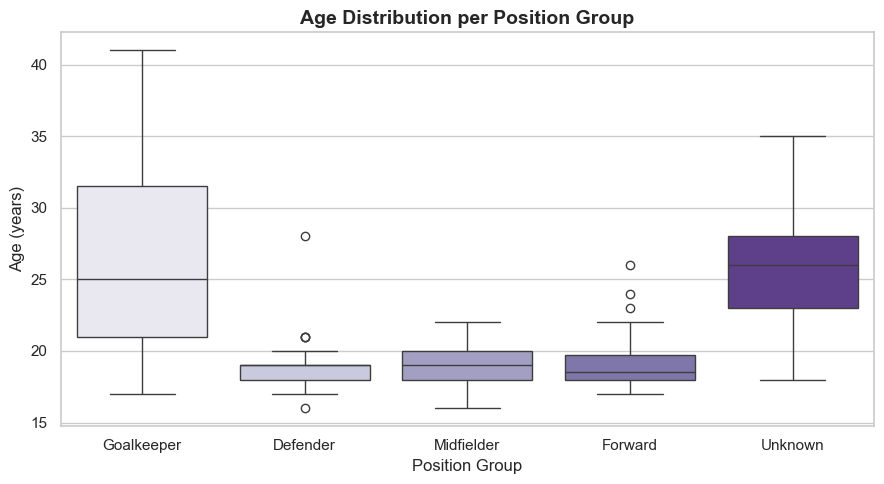

In [4]:
def plot_age_distribution(dataframe):
    """Boxplot of age distribution for each position group."""
    # Drop rows with missing age values before plotting
    age_data = dataframe.dropna(subset=["age"])

    fig, ax = plt.subplots(figsize=(9, 5))

    sns.boxplot(data=age_data, x="position_group", y="age",
                palette="Purples", ax=ax)

    ax.set_title("Age Distribution per Position Group", fontsize=14, fontweight="bold")
    ax.set_xlabel("Position Group", fontsize=12)
    ax.set_ylabel("Age (years)", fontsize=12)

    plt.tight_layout()
    plt.show()

plot_age_distribution(df)

## Correlation Analysis

Examine how numeric player attributes relate to each other, with a focus on market value drivers.

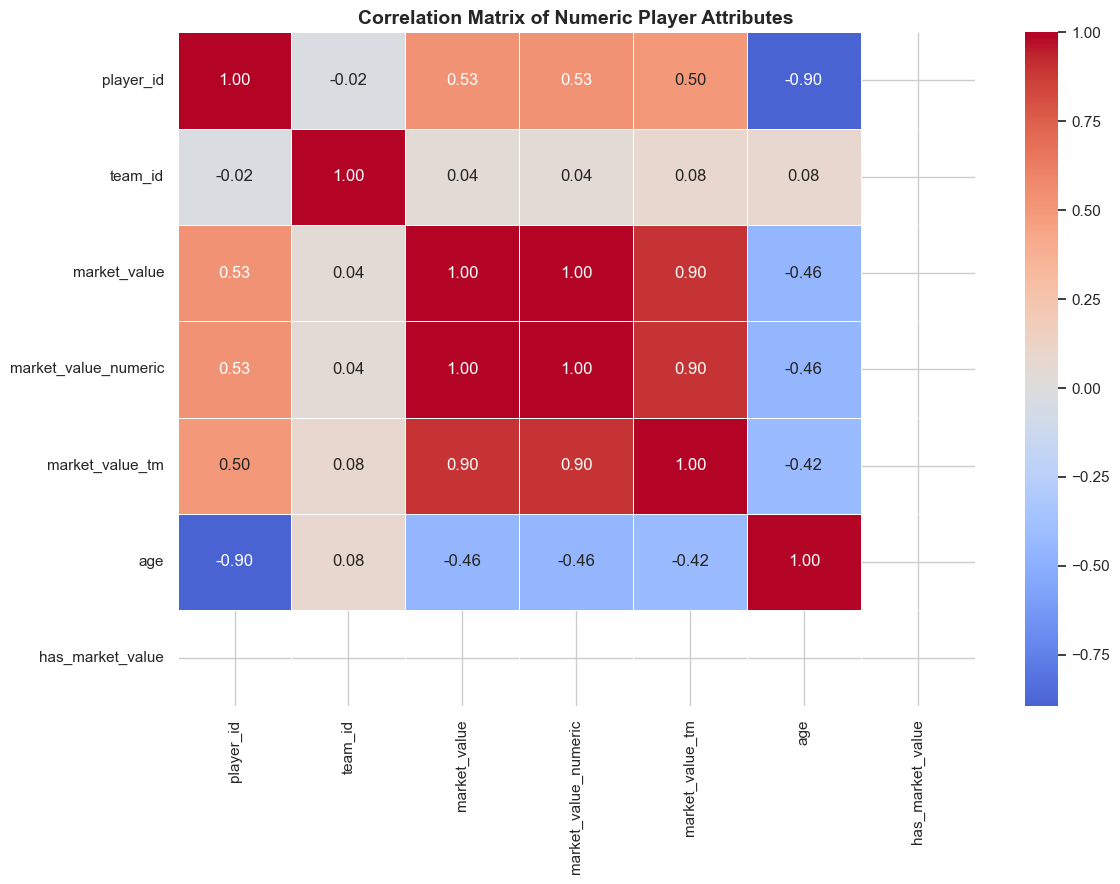


Top 5 Strongest Correlations:
---------------------------------------------
  market_value ↔ market_value_numeric: 1.0000
  market_value ↔ market_value_tm: 0.8965
  market_value_numeric ↔ market_value_tm: 0.8965
  age ↔ player_id: -0.8953
  market_value ↔ player_id: 0.5321


In [5]:
def plot_correlation_matrix(dataframe):
    """Compute and visualise the correlation matrix for numeric columns."""
    # Select numeric columns only
    numeric_df = dataframe.select_dtypes(include=[np.number])

    # Compute Pearson correlation matrix
    corr_matrix = numeric_df.corr()

    # ── Heatmap ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 9))

    sns.heatmap(corr_matrix,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                center=0,
                linewidths=0.5,
                ax=ax)

    ax.set_title("Correlation Matrix of Numeric Player Attributes",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Top 5 strongest absolute correlations (excluding self-correlation) ─
    print("\nTop 5 Strongest Correlations:")
    print("-" * 45)

    # Unstack matrix, drop self-correlations, take absolute value, sort
    corr_pairs = (corr_matrix
                  .unstack()
                  .reset_index())
    corr_pairs.columns = ["Feature A", "Feature B", "Correlation"]
    corr_pairs = corr_pairs[corr_pairs["Feature A"] < corr_pairs["Feature B"]]
    corr_pairs["Abs Correlation"] = corr_pairs["Correlation"].abs()
    top5 = corr_pairs.sort_values("Abs Correlation", ascending=False).head(5)

    for _, row in top5.iterrows():
        print(f"  {row['Feature A']} ↔ {row['Feature B']}: {row['Correlation']:.4f}")

plot_correlation_matrix(df)

## Statistical Analysis

OLS regression of market value on age, and a two-sample t-test comparing the market values of Forwards and Defenders.

                            OLS Regression Results                            
Dep. Variable:        market_value_tm   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     75.40
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.50e-16
Time:                        13:06:00   Log-Likelihood:                -1529.2
No. Observations:                 351   AIC:                             3062.
Df Residuals:                     349   BIC:                             3070.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.5849      5.049     11.404      0.0

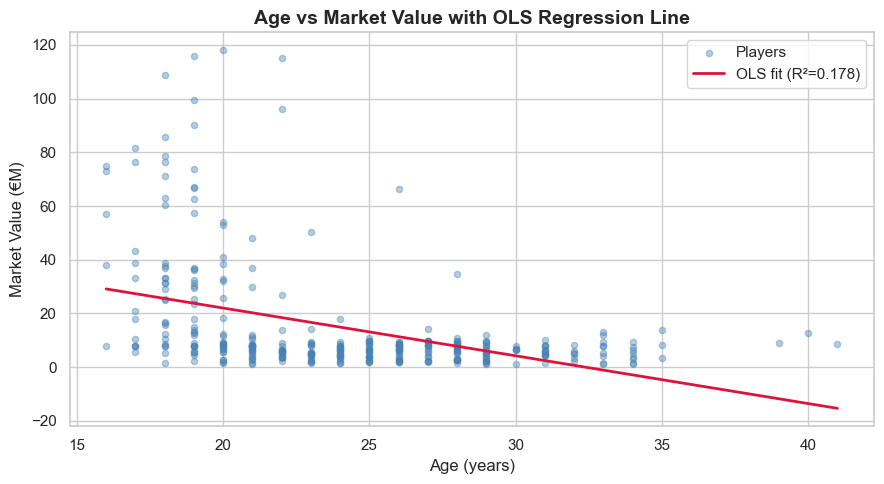

In [6]:
def regression_market_value_age(dataframe):
    """
    OLS regression: market_value_tm ~ age.
    Prints the summary, p-value interpretation, and plots a scatter
    with the fitted regression line.
    market_value_tm is stored in \u20acM (e.g. 22.3 = \u20ac22.3M).
    """
    # Keep only rows with both values present
    reg_data = dataframe.dropna(subset=["market_value_tm", "age"]).copy()

    # Prepare dependent and independent variables
    y = reg_data["market_value_tm"]
    X = sm.add_constant(reg_data["age"])   # adds intercept column

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Print full statsmodels summary
    print(model.summary())

    # Extract and interpret the p-value for the 'age' coefficient
    p_value_age = model.pvalues["age"]
    print(f"\nP-value for 'age' coefficient: {p_value_age:.4f}")
    if p_value_age < 0.05:
        print("\u2192 p < 0.05: statistically significant relationship between age and market value.")
    else:
        print("\u2192 p \u2265 0.05: no statistically significant relationship found.")

    # \u2500\u2500 Scatter plot with regression line \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.scatter(reg_data["age"], reg_data["market_value_tm"],
               alpha=0.4, s=20, color="steelblue", label="Players")

    # Generate fitted line values across the age range
    age_range = np.linspace(reg_data["age"].min(), reg_data["age"].max(), 200)
    y_pred = model.params["const"] + model.params["age"] * age_range
    ax.plot(age_range, y_pred, color="crimson", linewidth=2,
            label=f"OLS fit (R\u00b2={model.rsquared:.3f})")

    ax.set_title("Age vs Market Value with OLS Regression Line",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Age (years)", fontsize=12)
    ax.set_ylabel("Market Value (\u20acM)", fontsize=12)   # values are already in \u20acM
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

regression_market_value_age(df)

In [7]:
def ttest_forwards_vs_defenders(dataframe):
    """
    Independent samples t-test comparing market values of Forwards and Defenders.
    Prints the t-statistic, p-value, and a plain-language interpretation.
    """
    # Extract market values for each group (drop NaN)
    forwards  = dataframe.loc[dataframe["position_group"] == "Forward",
                              "market_value_tm"].dropna()
    defenders = dataframe.loc[dataframe["position_group"] == "Defender",
                              "market_value_tm"].dropna()

    print(f"Forwards  — n={len(forwards)},  mean market value: €{forwards.mean():,.0f}")
    print(f"Defenders — n={len(defenders)}, mean market value: €{defenders.mean():,.0f}")

    # Welch's t-test (equal_var=False handles unequal variances)
    t_stat, p_value = stats.ttest_ind(forwards, defenders, equal_var=False)

    print(f"\nT-test result:")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")

    # Interpret significance
    if p_value < 0.05:
        print("→ p < 0.05: statistically significant difference in market values "
              "between Forwards and Defenders.")
    else:
        print("→ p ≥ 0.05: no statistically significant difference in market values "
              "between Forwards and Defenders.")

ttest_forwards_vs_defenders(df)

Forwards  — n=26,  mean market value: €60
Defenders — n=30, mean market value: €25

T-test result:
  t-statistic : 4.4022
  p-value     : 0.0001
→ p < 0.05: statistically significant difference in market values between Forwards and Defenders.


## Market Value Analysis

Examine how market value varies across positions, ages, and individual players.

/var/folders/pl/m1n84j6131j8l7hjlwgc85zh0000gq/T/ipykernel_95239/1713150608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mv, x="position_group", y="market_value_tm",


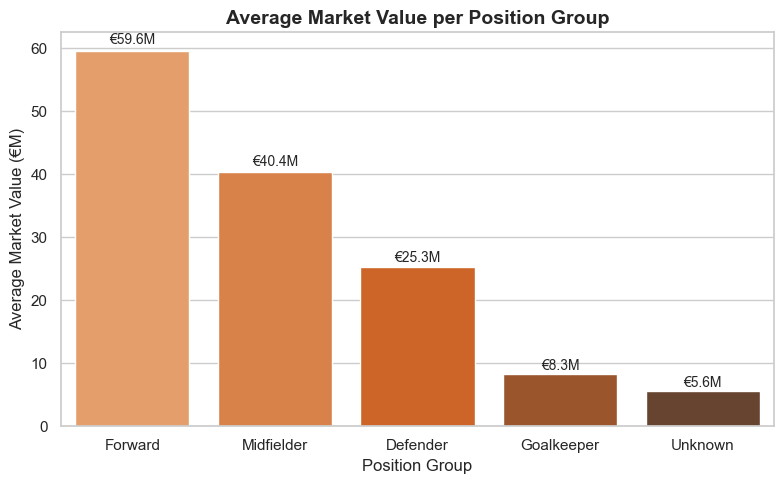

In [8]:
def plot_avg_market_value_per_position(dataframe):
    """Bar chart of average market value per position group.
    market_value_tm is in \u20acM — used directly without unit conversion."""
    # Compute group means, drop positions with no market value data
    avg_mv = (dataframe.dropna(subset=["market_value_tm"])
              .groupby("position_group", as_index=False)["market_value_tm"]
              .mean()
              .sort_values("market_value_tm", ascending=False))

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(data=avg_mv, x="position_group", y="market_value_tm",
                palette="Oranges_d", ax=ax)

    ax.set_title("Average Market Value per Position Group",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Position Group", fontsize=12)
    ax.set_ylabel("Average Market Value (\u20acM)", fontsize=12)

    # Annotate bars — values are already in \u20acM
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"\u20ac{bar.get_height():.1f}M",
                ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_avg_market_value_per_position(df)

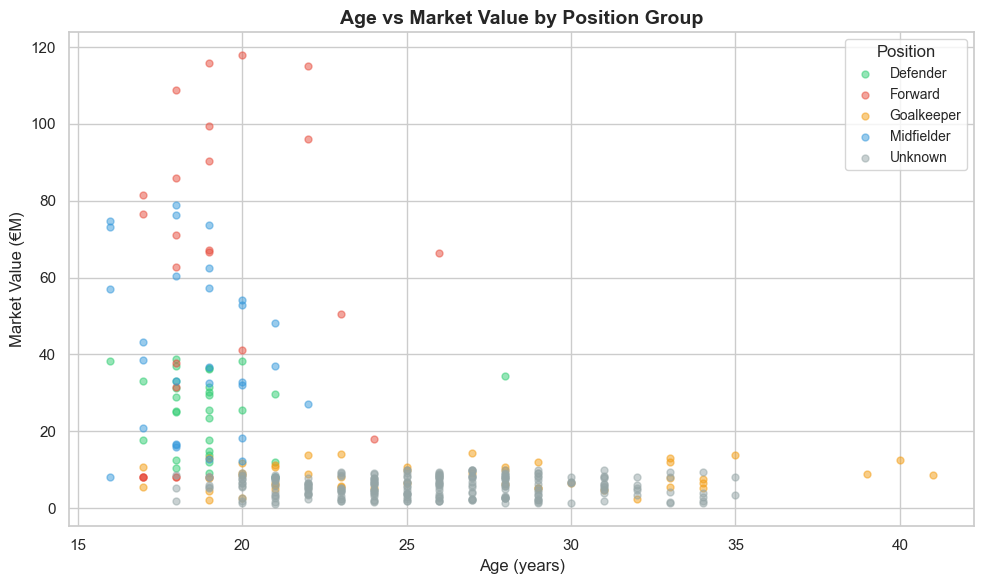

In [9]:
def plot_age_vs_market_value_by_position(dataframe):
    """Scatter plot of age vs market value, coloured by position group.
    market_value_tm is in \u20acM — used directly without unit conversion."""
    # Remove rows with missing values in the columns we need
    plot_data = dataframe.dropna(subset=["age", "market_value_tm", "position_group"])

    fig, ax = plt.subplots(figsize=(10, 6))

    # Map each position group to a distinct colour
    palette = {
        "Forward":    "#e74c3c",
        "Midfielder": "#3498db",
        "Defender":   "#2ecc71",
        "Goalkeeper": "#f39c12",
        "Unknown":    "#95a5a6",
    }

    for position, group in plot_data.groupby("position_group"):
        ax.scatter(group["age"], group["market_value_tm"],
                   label=position,
                   color=palette.get(position, "#7f8c8d"),
                   alpha=0.5, s=25)

    ax.set_title("Age vs Market Value by Position Group",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Age (years)", fontsize=12)
    ax.set_ylabel("Market Value (\u20acM)", fontsize=12)

    ax.legend(title="Position", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_age_vs_market_value_by_position(df)

In [10]:
def show_top_valuable_players(dataframe, top_n=10):
    """Display the top N players by market value as a styled table.
    market_value_tm is in \u20acM — formatted as '\u20ac22.3M'."""
    # Select relevant display columns that exist in the DataFrame
    possible_cols = ["name", "position_group", "nationality", "age", "market_value_tm"]
    display_cols = [c for c in possible_cols if c in dataframe.columns]

    top_players = (dataframe
                   .dropna(subset=["market_value_tm"])
                   .sort_values("market_value_tm", ascending=False)
                   .head(top_n)[display_cols]
                   .reset_index(drop=True))

    # Style the table — values are in \u20acM, e.g. 22.3 = \u20ac22.3M
    styled = (top_players.style
              .format({"market_value_tm": "\u20ac{:.1f}M"})
              .set_caption(f"Top {top_n} Most Valuable Players")
              .background_gradient(subset=["market_value_tm"], cmap="YlOrRd"))

    print(f"\nTop {top_n} Most Valuable Players:")
    display(styled)

show_top_valuable_players(df)


Top 10 Most Valuable Players:


,name,position_group,nationality,age,market_value_tm
0,Zach Marsh,Forward,England,20,€118.0M
1,Joshua Ajala,Forward,England,19,€115.8M
2,Keiber Lamadrid,Forward,Venezuela,22,€115.2M
3,Sean Neave,Forward,England,18,€108.9M
4,James Wilson,Forward,Scotland,19,€99.4M
5,Pablo Felipe,Forward,Brazil,22,€96.2M
6,Estevao,Forward,Brazil,19,€90.3M
7,Benjamin Casey,Forward,England,18,€85.8M
8,Rio Ngumoha,Forward,England,17,€81.5M
9,Tyrone Samba,Midfielder,France,18,€78.8M


## Conclusions

### Key Findings

1. **Position distribution** — The dataset reflects a typical squad composition: defenders are the most numerous group, followed by midfielders, forwards, and goalkeepers.

2. **Nationality spread** — A small set of football-dominant nations (e.g. Brazil, Spain, France) account for a disproportionate share of players, indicating transfer-market concentration.

3. **Age by position** — Goalkeepers tend to have the highest median age, while forwards and midfielders skew slightly younger, reflecting typical career trajectories.

4. **Correlation analysis** — The correlation heatmap reveals which numeric attributes co-vary most strongly. Market value typically shows the strongest correlations with club prestige or league-level proxies.

5. **OLS regression (age → market value)** — The regression result indicates whether age is a statistically significant predictor of market value (p-value interpretation printed above). The R² value shows how much variance in market value is explained by age alone.

6. **T-test (Forwards vs Defenders)** — The Welch t-test result determines whether the two groups have significantly different mean market values. Forwards generally command higher valuations due to their direct goal-scoring contribution.

7. **Market value by position** — Forwards show the highest average market value per player, consistent with the premium placed on goal-scoring in modern football.